In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Reading in the csv file

In [97]:
data = "C:/Users/udip49yc/Python/eda.csv"

df = pd.read_csv(data)

Checking dimensions of the data

In [98]:
df.shape

(10, 10)

We can view the top five and bottom five rows of the dataset with df.head() and df.tail() methods respectively.

In [99]:
df.head()

,fname,lname,age_sex,section,height(cm),weight(kg),age,spend_A,spend_B,spend_C
0,Harry,Potter,37_M,B,175.4,85.6,37,1500.0,200.0,300.0
1,Hermione,Granger,38_F,B,NaN,NaN,38,NaN,1000.0,NaN
2,Ron,Weasley,35_M,B,165.1,NaN,35,500.0,-100.0,200.0
3,Cho,Chang,40_F,A,0,55.6,40,300.0,300.0,NaN
4,Neville,Longbottom,39_M,B,160.8,160.0,39,200.0,NaN,300.0


In [100]:
df.tail()

,fname,lname,age_sex,section,height(cm),weight(kg),age,spend_A,spend_B,spend_C
5,Padma,Patil,36_F,A,NaN,-60.0,36,100.0,400.0,NaN
6,Luna,Lovegood,35_D,C,xx,75.5,35,NaN,500.0,500.0
7,Cedric,Diggory,34_M,C,155.1,56.8,34,1000.0,100.0,NaN
8,Bellatrix,Lestrange,36_F,C,154.2,60.6,36,100.0,200.0,300.0
9,Severus,Snape,68_M,A,162.1,58.7,38,600.0,200.0,200.0


We can get a concise summary of the dataset with df.info() method. This method prints information about a DataFrame including the index dtype and column dtypes, non-null values and memory usage.

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fname       10 non-null     object 
 1   lname       10 non-null     object 
 2   age_sex     10 non-null     object 
 3   section     10 non-null     object 
 4   height(cm)  8 non-null      object 
 5   weight(kg)  8 non-null      float64
 6   age         10 non-null     int64  
 7   spend_A     8 non-null      float64
 8   spend_B     9 non-null      float64
 9   spend_C     6 non-null      float64
dtypes: float64(4), int64(1), object(5)
memory usage: 932.0+ bytes


We can check the data types of each column in the dataframe with df.dtypes attribute. The above command returns the data type of each column.

In [102]:
df.dtypes

fname          object
lname          object
age_sex        object
section        object
height(cm)     object
weight(kg)    float64
age             int64
spend_A       float64
spend_B       float64
spend_C       float64
dtype: object

There is an invalid value coded as "xx" in the height(cm) column. We can coerce invalid values to "NaN" using the errors keyword

In [103]:
df["height(cm)"] = pd.to_numeric(df["height(cm)"], errors='coerce')

Checking the data types now

In [104]:
df.dtypes

fname          object
lname          object
age_sex        object
section        object
height(cm)    float64
weight(kg)    float64
age             int64
spend_A       float64
spend_B       float64
spend_C       float64
dtype: object

Let us view the summary statistics of numerical columns with df.describe() method. It enable us to detect outliers in the data which require further investigation.

In [105]:
df.describe()

,height(cm),weight(kg),age,spend_A,spend_B,spend_C
count,7.000000,8.000000,10.000000,8.000000,9.000000,6.000000
mean,138.957143,61.600000,36.800000,537.500000,311.111111,300.000000
std,61.679625,60.126985,1.932184,492.624169,310.017921,109.544512
min,0.000000,-60.000000,34.000000,100.000000,-100.000000,200.000000
25%,154.650000,56.500000,35.250000,175.000000,200.000000,225.000000
50%,160.800000,59.650000,36.500000,400.000000,200.000000,300.000000
75%,163.600000,78.025000,38.000000,700.000000,400.000000,300.000000
max,175.400000,160.000000,40.000000,1500.000000,1000.000000,500.000000


In [ ]:

df = df.drop(columns=['section','spend_A', 'spend_B', 'spend_C'])
df.columns

Index(['fname', 'lname', 'age_sex', 'height(cm)', 'weight(kg)', 'age'], dtype='object')

We should split the 'age_sex' column into two separate columns.

We can do this using the df.str.split() function

In [107]:
df[['age','sex']] = df.age_sex.str.split("_", expand = True)
df.head()


,fname,lname,age_sex,height(cm),weight(kg),age,sex
0,Harry,Potter,37_M,175.4,85.6,37,M
1,Hermione,Granger,38_F,NaN,NaN,38,F
2,Ron,Weasley,35_M,165.1,NaN,35,M
3,Cho,Chang,40_F,0.0,55.6,40,F
4,Neville,Longbottom,39_M,160.8,160.0,39,M


In [108]:
df.drop(['age_sex'], axis=1, inplace=True)
df

,fname,lname,height(cm),weight(kg),age,sex
0,Harry,Potter,175.4,85.6,37,M
1,Hermione,Granger,NaN,NaN,38,F
2,Ron,Weasley,165.1,NaN,35,M
3,Cho,Chang,0.0,55.6,40,F
4,Neville,Longbottom,160.8,160.0,39,M
5,Padma,Patil,NaN,-60.0,36,F
6,Luna,Lovegood,NaN,75.5,35,D
7,Cedric,Diggory,155.1,56.8,34,M
8,Bellatrix,Lestrange,154.2,60.6,36,F
9,Severus,Snape,162.1,58.7,68,M


We have seen that, in the weight(kg) column, there is a negative value of -60. It is invalid value because weight cannot be negative. There is a high probability that weight is 60 kg and it is mistyped as -60. So, I will replace the negative value of -60 with positive value of 60.

In [109]:
df['weight(kg)'].replace(-60, 60, inplace=True)


df



C:\Users\udip49yc\AppData\Local\Temp\ipykernel_2384\207775432.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weight(kg)'].replace(-60, 60, inplace=True)


,fname,lname,height(cm),weight(kg),age,sex
0,Harry,Potter,175.4,85.6,37,M
1,Hermione,Granger,NaN,NaN,38,F
2,Ron,Weasley,165.1,NaN,35,M
3,Cho,Chang,0.0,55.6,40,F
4,Neville,Longbottom,160.8,160.0,39,M
5,Padma,Patil,NaN,60.0,36,F
6,Luna,Lovegood,NaN,75.5,35,D
7,Cedric,Diggory,155.1,56.8,34,M
8,Bellatrix,Lestrange,154.2,60.6,36,F
9,Severus,Snape,162.1,58.7,68,M


In the height(cm) column, there is a value of 0.0. It is not possible as height cannot be 0. So, we need to resolve it.

I will replace the 0.0 value with the mean of the height(cm) column.

In [110]:
mean = df['height(cm)'].mean()



# df['height(cm)'] = df['height(cm)'].replace(0.0, mean, inplace=True)
df['height(cm)'] = df['height(cm)'].fillna(mean)


df

,fname,lname,height(cm),weight(kg),age,sex
0,Harry,Potter,175.400000,85.6,37,M
1,Hermione,Granger,138.957143,NaN,38,F
2,Ron,Weasley,165.100000,NaN,35,M
3,Cho,Chang,0.000000,55.6,40,F
4,Neville,Longbottom,160.800000,160.0,39,M
5,Padma,Patil,138.957143,60.0,36,F
6,Luna,Lovegood,138.957143,75.5,35,D
7,Cedric,Diggory,155.100000,56.8,34,M
8,Bellatrix,Lestrange,154.200000,60.6,36,F
9,Severus,Snape,162.100000,58.7,68,M


We can also check the number of missing values in each column in the dataset 

In [111]:


df.isnull().sum()



fname         0
lname         0
height(cm)    0
weight(kg)    2
age           0
sex           0
dtype: int64

In [112]:
df["age"] = pd.to_numeric(df["age"], errors='coerce')
df.dtypes

fname          object
lname          object
height(cm)    float64
weight(kg)    float64
age             int64
sex            object
dtype: object

Visual Exploratory Data Analysis

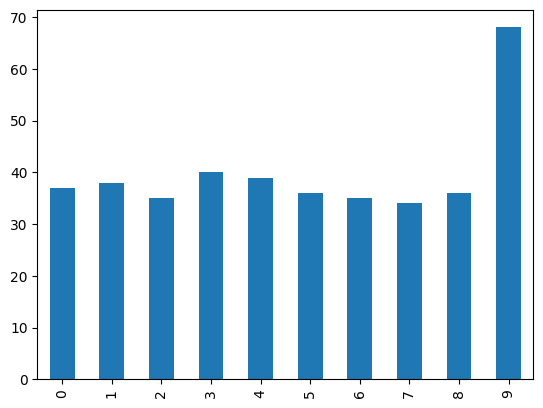

In [113]:
df['age'].plot(kind='bar')

plt.show()